<a href="https://colab.research.google.com/github/RachmadAprisandhy/PembelajaranMesin/blob/main/JS04/JS04_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
path = '/content/drive/MyDrive/Pembelajaran mesin/insurance.csv'
data = pd.read_csv(path)

1. cek datanya

In [6]:
	# melihat beberapa data awal
	data.head()

	# mengecek ukuran data
	data.shape

	# informasi tentang data
	data.info()

	# deskripsi data
	data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


1. Identifikasi variabel-variabel yang akan digunakan sebagai variabel bebas (fitur) dan variabel target (biaya medis personal).

variabel yang menjadi target adalah variable charges
sementara yang fitur ada age,sex,bmi,children,smoker,region

ariabel target pada dataset adalah charges, yang menunjukkan biaya medis personal dan menjadi nilai yang akan diprediksi. Sementara itu, variabel bebas atau fitur yang digunakan adalah age, sex, bmi, children, smoker, dan region. Variabel-variabel tersebut digunakan sebagai faktor yang membantu model dalam memprediksi nilai biaya medis personal (charges).

ubah dulu variabel string atau tulisan ke angka untuk emmudahkan pengerjaan

In [7]:
# Mengubah data kategorikal menjadi numerik
data_encoded = pd.get_dummies(
    data,
    columns=['sex', 'smoker', 'region'],
    drop_first=True
)

data_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


bagi fitur jadi target dan fitur

In [8]:
# Variabel bebas (X)
X = data_encoded.drop('charges', axis=1)

# Variabel target (y)
y = data_encoded['charges']

print("Variabel bebas:")
print(X.columns.tolist())

print("\nVariabel target:")
print(y.name)

Variabel bebas:
['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']

Variabel target:
charges


2. Membagi dataset menjadi data train dan test

In [9]:
# Split data
from sklearn.model_selection import train_test_split

# Split data training dan data lainnya
# Rasio awal 80% training dan 20% data lainnya
X_train, X_unseen, y_train, y_unseen = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0
)

# Data lainnya dibagi lagi menjadi validasi dan testing
# Masing-masing 10% dari keseluruhan data
X_val, X_test, y_val, y_test = train_test_split(
    X_unseen,
    y_unseen,
    test_size=0.5,
    random_state=0
)

# Cek ukuran masing-masing data
print(f'Jumlah data asli   : {len(X)}')
print(f'Jumlah data train  : {len(X_train)}')
print(f'Jumlah data val    : {len(X_val)}')
print(f'Jumlah data test   : {len(X_test)}')

Jumlah data asli   : 1338
Jumlah data train  : 1070
Jumlah data val    : 134
Jumlah data test   : 134


3.
Lakukan feature scaling jika diperlukan.

In [10]:
from sklearn.preprocessing import StandardScaler

sc_X = StandardScaler()

X_train_scaled = sc_X.fit_transform(X_train)
X_val_scaled = sc_X.transform(X_val)
X_test_scaled = sc_X.transform(X_test)

4. Buat model multiple linear regression menggunakan Scikit-Learn.

In [11]:
from sklearn.linear_model import LinearRegression
# Membuat model Multiple Linear Regression
model_lr = LinearRegression()

5. Latih model pada data latih dan lakukan prediksi pada data uji.

In [12]:
# Melatih model menggunakan data training
model_lr.fit(X_train, y_train)

# Melakukan prediksi terhadap data testing
y_pred_lr = model_lr.predict(X_test)

hasil_prediksi = pd.DataFrame({
    'Aktual': y_test.values,
    'Prediksi': y_pred_lr
})

hasil_prediksi.head(10)

,Aktual,Prediksi
0,6334.34355,10080.411547
1,8605.36150,6807.280015
2,7147.10500,6556.707768
3,7441.05300,9394.023622
4,4428.88785,3698.099728
5,6500.23590,7858.629226
6,12265.50690,14941.661011
7,13112.60480,11725.885742
8,10702.64240,10715.115820
9,7537.16390,9012.579696


6. Evaluasi model menggunakan R², MSE, dan MAE

In [13]:
# Menghitung evaluasi model
r2_lr = r2_score(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("=== Evaluasi Multiple Linear Regression ===")
print(f"R-squared : {r2_lr:.4f}")
print(f"MSE       : {mse_lr:.2f}")
print(f"MAE       : {mae_lr:.2f}")

=== Evaluasi Multiple Linear Regression ===
R-squared : 0.7613
MSE       : 37666132.72
MAE       : 4147.25


visualisasi

a. scatter plot

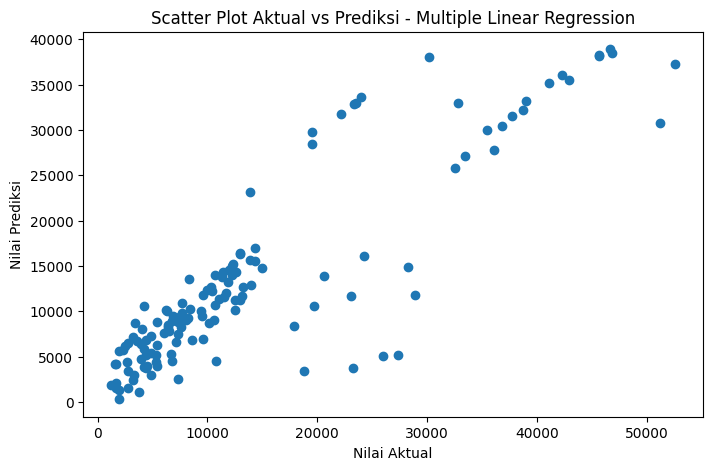

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred_lr)

plt.xlabel('Nilai Aktual')
plt.ylabel('Nilai Prediksi')
plt.title('Scatter Plot Aktual vs Prediksi - Multiple Linear Regression')

plt.show()

b. line plot

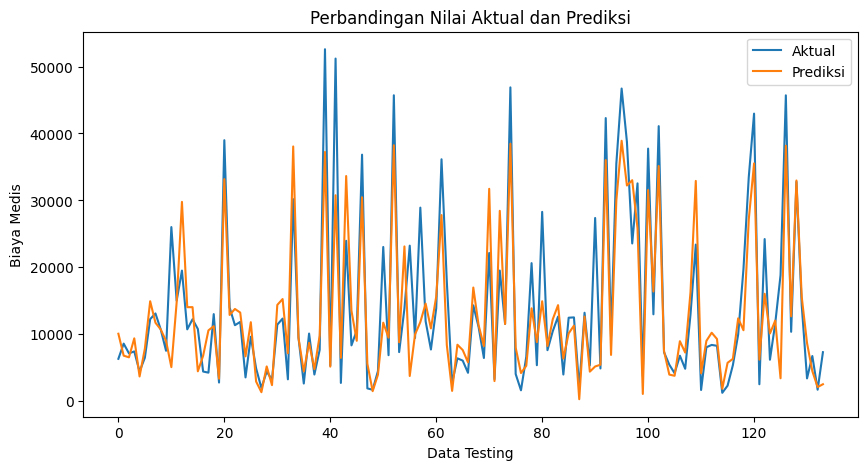

In [16]:
plt.figure(figsize=(10, 5))

plt.plot(
    y_test.values,
    label='Aktual'
)

plt.plot(
    y_pred_lr,
    label='Prediksi'
)

plt.xlabel('Data Testing')
plt.ylabel('Biaya Medis')
plt.title('Perbandingan Nilai Aktual dan Prediksi')

plt.legend()

plt.show()

7.
Ulagi langkah 4 dengan menggunakan model SVR. Anda dapat bereksperimen dengan dengan melakukan hyperparameter tunning.

Fitting model SVR

In [17]:
# Fitting SVR ke dataset
from sklearn.svm import SVR

regressor = SVR(kernel='rbf')
regressor.fit(X_train_scaled, y_train)

SVR()

Prediksi Hasil SVR

In [18]:
# Prediksi hasil
y_pred_svr = regressor.predict(X_test_scaled)

print("Hasil prediksi SVR:")
print(y_pred_svr[:5])

Hasil prediksi SVR:
[9416.4440107  9432.34092164 9421.45613409 9416.60655304 9386.70827985]


Evaluasi Model SVR

In [19]:
# Evaluasi model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_actual = y_test
y_pred = y_pred_svr

# Menghitung MAE
mae = mean_absolute_error(y_actual, y_pred)

# Menghitung MSE
mse = mean_squared_error(y_actual, y_pred)

# Menghitung RMSE
rmse = np.sqrt(mse)

# Menghitung R-squared
r2 = r2_score(y_actual, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R-squared:", r2)

MAE: 8808.903325403422
MSE: 179251883.17545214
RMSE: 13388.498167287178
R-squared: -0.13610774229663058


Visualisasi Hasil SVR

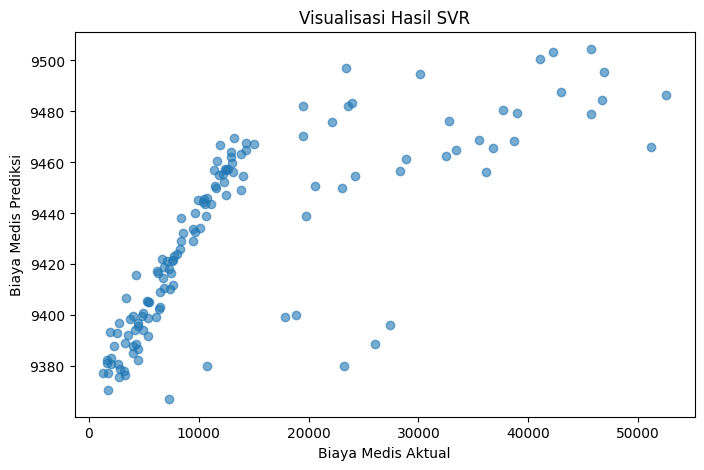

In [23]:
# Visualisasi hasil SVR
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_svr, alpha=0.6)

plt.xlabel('Biaya Medis Aktual')
plt.ylabel('Biaya Medis Prediksi')
plt.title('Visualisasi Hasil SVR')

plt.show()

analisis

Berdasarkan hasil praktikum yang telah dilakukan pada dataset Medical Cost Personal Dataset, terdapat beberapa metode yang digunakan untuk melakukan prediksi biaya medis, yaitu Multiple Linear Regression dan Support Vector Regression (SVR). Dataset memiliki beberapa fitur seperti usia, jenis kelamin, BMI, jumlah anak, status perokok, dan wilayah tempat tinggal, dengan charges sebagai variabel target.

Pada Multiple Linear Regression, model digunakan untuk mengetahui hubungan antara beberapa variabel independen terhadap biaya medis. Sementara itu, SVR digunakan sebagai metode pembanding dengan memanfaatkan proses feature scaling agar setiap fitur memiliki skala yang sesuai.

Evaluasi kedua model dilakukan menggunakan MAE (Mean Absolute Error), MSE (Mean Squared Error), dan R-squared (R²). Nilai MAE menunjukkan rata-rata selisih antara biaya medis aktual dan hasil prediksi, sedangkan MSE menunjukkan rata-rata kuadrat kesalahan prediksi. Nilai R² menunjukkan seberapa baik model dalam menjelaskan variasi pada data target. Semakin kecil nilai MAE dan MSE, serta semakin besar nilai R², menunjukkan hasil prediksi yang semakin mendekati data aktual.

Berdasarkan visualisasi aktual dan prediksi, dapat dilihat seberapa dekat hasil prediksi model terhadap nilai biaya medis sebenarnya. Visualisasi tersebut membantu menunjukkan tingkat kesesuaian hasil prediksi yang tidak hanya dapat dilihat dari nilai metrik evaluasi.

Secara keseluruhan, penggunaan Multiple Linear Regression dan SVR memberikan gambaran mengenai penerapan metode regresi untuk memprediksi biaya medis. Perbedaan hasil evaluasi dari kedua model dapat digunakan untuk melihat karakteristik model dalam menangani data dengan beberapa variabel numerik dan kategorikal yang telah dilakukan encoding sebelumnya.